#  CALIFORNIA WILDFIRE CRISIS: A DATA STORY (2013-2019)
#  Midterm Data Storytelling Assignment
#  Dhanshree Patil

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
import numpy as np
import warnings
warnings.filterwarnings('ignore')

In [2]:
print("=" * 62)
print("  CALIFORNIA WILDFIRE CRISIS — DATA STORYTELLING")
print("=" * 62)

  CALIFORNIA WILDFIRE CRISIS — DATA STORYTELLING


In [3]:
# ── LOAD ─────────────────────────────────────────────────────
print("\n[1/5] Loading dataset...")
df = pd.read_csv('California_Fire_Incidents.csv')
print(f"      Rows: {df.shape[0]}, Columns: {df.shape[1]}")


[1/5] Loading dataset...
      Rows: 1636, Columns: 38


In [4]:
# ── CLEAN ────────────────────────────────────────────────────
print("\n[2/5] Cleaning data...")
cols = ['ArchiveYear','Name','Counties','AcresBurned',
        'StructuresDestroyed','Fatalities','Injuries','MajorIncident','Started']
df_clean = df[cols].copy()
df_clean = df_clean.dropna(subset=['AcresBurned'])
df_clean = df_clean[df_clean['AcresBurned'] > 0]
for col in ['StructuresDestroyed','Fatalities','Injuries']:
    df_clean[col] = df_clean[col].fillna(0).astype(int)
df_clean['Started'] = pd.to_datetime(df_clean['Started'], errors='coerce')
df_clean['Month']   = df_clean['Started'].dt.month
df_county = df_clean[~df_clean['Counties'].str.contains(',', na=True)].copy()
print(f"      Cleaned rows: {len(df_clean)}, Single-county: {len(df_county)}")


[2/5] Cleaning data...
      Cleaned rows: 1605, Single-county: 1605


In [5]:
# ── AGGREGATE ────────────────────────────────────────────────
print("\n[3/5] Aggregating...")
yearly = (df_clean.groupby('ArchiveYear')
          .agg(TotalAcres=('AcresBurned','sum'),
               TotalStructures=('StructuresDestroyed','sum'),
               TotalFatalities=('Fatalities','sum'),
               Incidents=('Name','count'))
          .reset_index())

county_acres = (df_county.groupby('Counties')['AcresBurned']
                .sum().sort_values(ascending=False).head(10).reset_index())
county_acres.columns = ['County','TotalAcres']

df_scatter = df_clean[df_clean['StructuresDestroyed'] > 0].copy()
df_scatter = df_scatter[df_scatter['AcresBurned'] <= df_scatter['AcresBurned'].quantile(0.99)]

print("\n[4/5] Building charts...")


[3/5] Aggregating...

[4/5] Building charts...


In [6]:
# ── PALETTE ──────────────────────────────────────────────────
BG       = "#E2E2D0"
PANEL    = "#B8D089"
GRID     = "#928383"
BORDER   = "#77A366"
C_RED    = "#BC594E"
C_ORANGE = '#D4681E'
C_AMBER  = '#C8880A'
C_TEXT   = '#1A1A1A'
C_SUB    = '#5A5A5A'
C_CALL   = '#FEF6E8'
C_DNGR   = '#FDEDEC'

fire_cmap = LinearSegmentedColormap.from_list(
    'fire_light', ['#F4CFA1','#E2945A','#C75D1E','#B03020','#7B1818'])

plt.rcParams.update({
    'figure.facecolor': BG, 'axes.facecolor': PANEL,
    'axes.edgecolor': BORDER, 'axes.labelcolor': C_TEXT,
    'xtick.color': C_SUB, 'ytick.color': C_SUB,
    'text.color': C_TEXT, 'grid.color': GRID,
    'grid.linewidth': 0.7, 'font.family': 'DejaVu Sans',
    'axes.spines.top': False, 'axes.spines.right': False,})

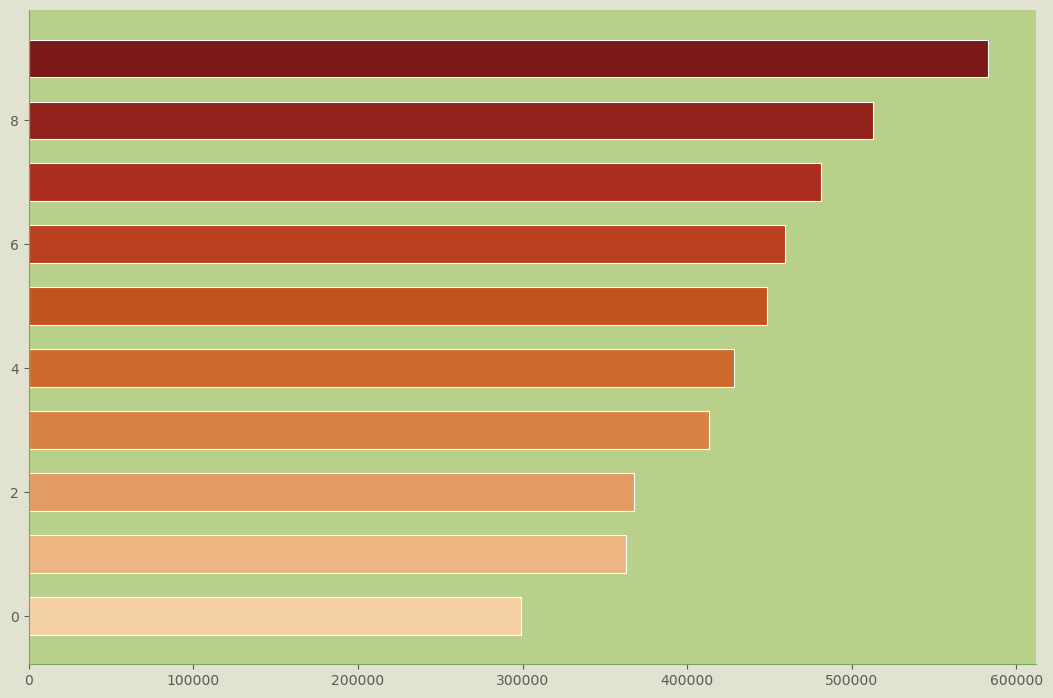

In [7]:
# BAR CHART

fig1, ax1 = plt.subplots(figsize=(13, 8.5))
fig1.patch.set_facecolor(BG)
ax1.set_facecolor(PANEL)

data_rev   = county_acres[::-1].reset_index(drop=True)
n          = len(data_rev)
bar_colors = [fire_cmap(i / (n-1)) for i in range(n)]

bars = ax1.barh(range(n), data_rev['TotalAcres'],
                color=bar_colors, edgecolor='white',
                linewidth=0.8, height=0.60)

In [8]:
# Value labels
for i, bar in enumerate(bars):
    w = bar.get_width()
    ax1.text(w + 6000, bar.get_y() + bar.get_height()/2,
             f'{int(w/1000):,}K acres',
             va='center', ha='left', fontsize=10.5,
             color=C_TEXT, fontweight='bold')


In [9]:
# County name labels
ax1.set_yticks(range(n))
ax1.set_yticklabels(data_rev['County'], fontsize=11.5, color=C_TEXT)

[Text(0, 0, 'Tuolumne'),
 Text(0, 1, 'Santa Barbara'),
 Text(0, 2, 'Siskiyou'),
 Text(0, 3, 'Glenn'),
 Text(0, 4, 'Ventura'),
 Text(0, 5, 'Shasta'),
 Text(0, 6, 'Colusa'),
 Text(0, 7, 'Trinity'),
 Text(0, 8, 'Mendocino'),
 Text(0, 9, 'Lake')]

In [10]:
# Rank badges
for i, row in data_rev.iterrows():
    rank = n - i
    fc   = C_RED if rank <= 3 else C_ORANGE
    ax1.text(-40000, i, f'#{rank}',
             va='center', ha='center', fontsize=8.5,
             color='white', fontweight='bold',
             bbox=dict(boxstyle='round,pad=0.35',
                       facecolor=fc, edgecolor='none'))

In [11]:
# Median line
med = county_acres['TotalAcres'].median()
ax1.axvline(med, color=C_SUB, linewidth=1.2, linestyle='--', alpha=0.6)
ax1.text(med + 3500, n - 0.35, 'median',
         fontsize=8.5, color=C_SUB, style='italic')

ax1.set_xlim(-72000, county_acres['TotalAcres'].max() * 1.22)
ax1.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x/1000):,}K'))
ax1.set_xlabel('Total Acres Burned (thousands)', fontsize=11, labelpad=10, color=C_SUB)
ax1.tick_params(axis='x', colors=C_SUB, labelsize=9)
ax1.tick_params(axis='y', length=0)
ax1.grid(axis='x', alpha=0.45, zorder=0)
ax1.spines['left'].set_visible(False)
ax1.spines['bottom'].set_color(BORDER)

In [12]:
# Callout box — inside plot, bottom-right
ax1.text(0.975, 0.03,
         '⚠  Top 3 counties: Lake, Mendocino & Trinity\n'
         '    accounted for over 40% of all acres burned\n'
         '    in California during 2013–2019.',
         transform=ax1.transAxes, fontsize=9.5,
         color=C_RED, ha='right', va='bottom',
         bbox=dict(boxstyle='round,pad=0.55',
                   facecolor=C_CALL, edgecolor=C_AMBER, linewidth=1.2))

Text(0.975, 0.03, '⚠  Top 3 counties: Lake, Mendocino & Trinity\n    accounted for over 40% of all acres burned\n    in California during 2013–2019.')

In [13]:
# Guiding question footer
fig1.text(0.08, 0.01,
          'Guiding Question: Which California counties bore the greatest cumulative wildfire burden between 2013 and 2019?',
          fontsize=9, color=C_SUB, style='italic',
          transform=fig1.transFigure)

Text(0.08, 0.01, 'Guiding Question: Which California counties bore the greatest cumulative wildfire burden between 2013 and 2019?')

In [14]:
# Title and subtitle — plenty of space, no overlap
fig1.text(0.08, 0.97, 'WHERE THE FIRES HIT HARDEST',
          fontsize=19, fontweight='bold', color=C_RED,
          transform=fig1.transFigure, va='top')
fig1.text(0.08, 0.93,
          'Top 10 California Counties by Cumulative Acres Burned, 2013–2019',
          fontsize=11.5, color=C_SUB,
          transform=fig1.transFigure, va='top')

plt.subplots_adjust(top=0.89, bottom=0.07, left=0.15, right=0.96)
plt.savefig('plot1_bar_counties.png', dpi=180,
            bbox_inches='tight', facecolor=BG)
plt.close()
print("Chart 1 saved → plot1_bar_counties.png")

Chart 1 saved → plot1_bar_counties.png


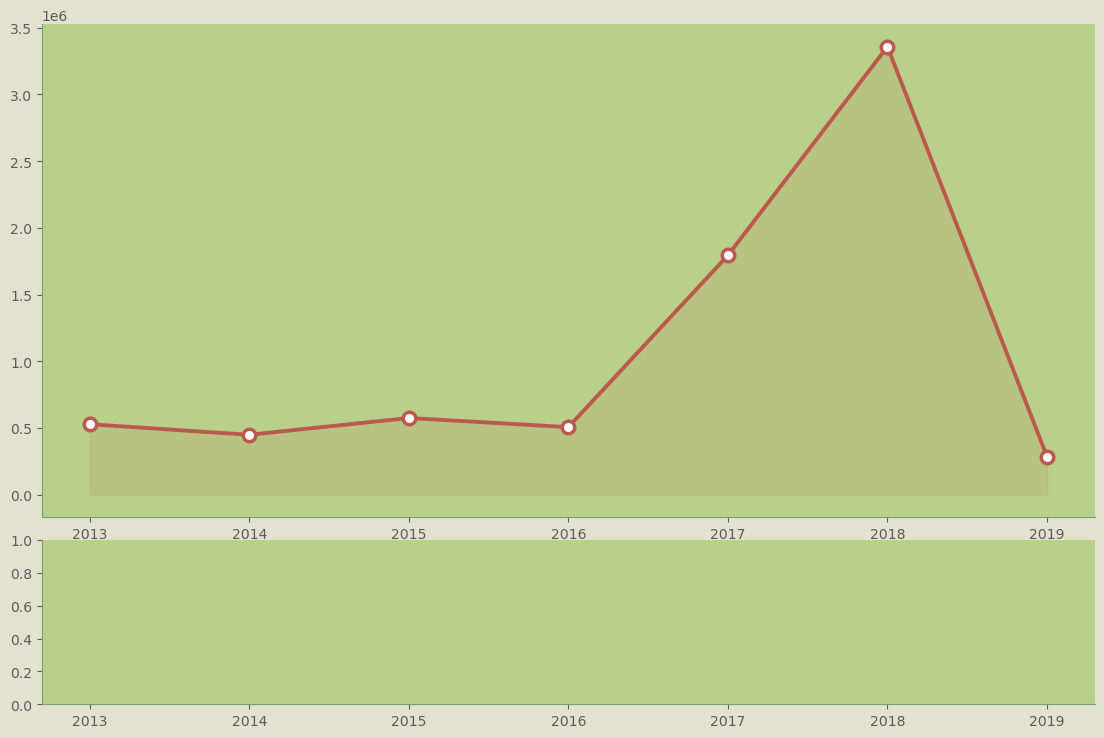

In [15]:
# LINE CHART 

fig2 = plt.figure(figsize=(13, 8.5))
fig2.patch.set_facecolor(BG)
gs = gridspec.GridSpec(2, 1, height_ratios=[3,1],
                       hspace=0.07, top=0.88, bottom=0.08,
                       left=0.10, right=0.91)
ax_m = fig2.add_subplot(gs[0])
ax_b = fig2.add_subplot(gs[1], sharex=ax_m)

ax_m.set_facecolor(PANEL)
ax_m.fill_between(yearly['ArchiveYear'], yearly['TotalAcres'],
                  alpha=0.10, color=C_RED, zorder=1)
ax_m.plot(yearly['ArchiveYear'], yearly['TotalAcres'],
          color=C_RED, linewidth=2.8, zorder=5,
          marker='o', markersize=9,
          markerfacecolor='white',
          markeredgecolor=C_RED, markeredgewidth=2.5,
          label='Acres Burned')

In [16]:
# Right axis
ax_r2 = ax_m.twinx()
ax_r2.set_facecolor('none')
ax_r2.plot(yearly['ArchiveYear'], yearly['TotalStructures'],
           color=C_ORANGE, linewidth=2.2, linestyle='--', zorder=4,
           marker='s', markersize=7,
           markerfacecolor='white',
           markeredgecolor=C_ORANGE, markeredgewidth=2,
           label='Structures Destroyed')
ax_r2.set_ylabel('Structures Destroyed', color=C_ORANGE,
                 fontsize=10.5, labelpad=10)
ax_r2.tick_params(axis='y', colors=C_ORANGE, labelsize=9)
ax_r2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))
ax_r2.spines['right'].set_color(C_ORANGE)
ax_r2.spines['right'].set_alpha(0.4)
ax_r2.spines['top'].set_visible(False)
ax_r2.spines['left'].set_visible(False)

In [17]:
# Annotate peaks
pk = yearly.loc[yearly['TotalAcres'].idxmax()]
ax_m.annotate(
    f"2018 PEAK\n{int(pk['TotalAcres']/1000):,}K acres\n(Camp Fire)",
    xy=(pk['ArchiveYear'], pk['TotalAcres']),
    xytext=(2015.8, pk['TotalAcres'] * 0.86),
    fontsize=9.5, color=C_RED, fontweight='bold',
    arrowprops=dict(arrowstyle='->', color=C_RED, lw=1.6,
                    connectionstyle='arc3,rad=0.28'),
    bbox=dict(boxstyle='round,pad=0.45', facecolor=C_CALL,
              edgecolor=C_RED, linewidth=1))

r17 = yearly[yearly['ArchiveYear']==2017].iloc[0]
ax_m.annotate(
    '2017: Wine Country Fires',
    xy=(2017, r17['TotalAcres']),
    xytext=(2014.5, r17['TotalAcres'] * 1.18),
    fontsize=9, color=C_ORANGE,
    arrowprops=dict(arrowstyle='->', color=C_ORANGE, lw=1.3),
    bbox=dict(boxstyle='round,pad=0.35', facecolor='#FEF9EF',
              edgecolor=C_ORANGE, linewidth=0.9))

ax_m.set_ylabel('Total Acres Burned', color=C_RED,
                fontsize=10.5, labelpad=10)
ax_m.tick_params(axis='y', colors=C_RED, labelsize=9)
ax_m.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x/1000):,}K'))
ax_m.spines['left'].set_color(C_RED)
ax_m.spines['left'].set_alpha(0.4)
ax_m.spines['bottom'].set_visible(False)
ax_m.tick_params(axis='x', which='both', length=0)
plt.setp(ax_m.get_xticklabels(), visible=False)
ax_m.grid(axis='y', alpha=0.35, zorder=0)
ax_m.set_xlim(2012.5, 2019.5)

l1, b1 = ax_m.get_legend_handles_labels()
l2, b2 = ax_r2.get_legend_handles_labels()
ax_m.legend(l1+l2, b1+b2, loc='upper left', fontsize=9.5,
            facecolor=PANEL, edgecolor=BORDER,
            labelcolor=C_TEXT, framealpha=0.95)

In [18]:
# Sub-bar
ax_b.set_facecolor(PANEL)
inc_colors = [C_RED if y >= 2017 else '#BBBBBB' for y in yearly['ArchiveYear']]
ax_b.bar(yearly['ArchiveYear'], yearly['Incidents'],
         color=inc_colors, edgecolor='white', linewidth=0.5,
         width=0.6, zorder=3)
for yr, val in zip(yearly['ArchiveYear'], yearly['Incidents']):
    ax_b.text(yr, val + 4, str(int(val)), ha='center',
              fontsize=8, color=C_SUB)

ax_b.set_ylabel('# Fires', color=C_SUB, fontsize=9.5, labelpad=6)
ax_b.tick_params(axis='y', colors=C_SUB, labelsize=8)
ax_b.tick_params(axis='x', colors=C_SUB, labelsize=10.5)
ax_b.set_xticks(yearly['ArchiveYear'])
ax_b.yaxis.set_major_locator(mticker.MaxNLocator(3))
ax_b.spines['bottom'].set_color(BORDER)
ax_b.spines['left'].set_color(BORDER)
ax_b.grid(axis='y', alpha=0.3, zorder=0)
ax_b.set_xlim(2012.5, 2019.5)

red_p  = mpatches.Patch(color=C_RED,    label='2017–2019 (elevated)')
grey_p = mpatches.Patch(color='#BBBBBB',label='2013–2016 (baseline)')
ax_b.legend(handles=[red_p, grey_p], fontsize=8.5,
            loc='upper left', facecolor=PANEL,
            edgecolor=BORDER, labelcolor=C_TEXT)

In [19]:
# Titles
fig2.text(0.10, 0.96, 'THE ESCALATING WILDFIRE CRISIS',
          fontsize=19, fontweight='bold', color=C_RED,
          transform=fig2.transFigure, va='top')
fig2.text(0.10, 0.92,
          'Annual Acres Burned & Structures Destroyed, California 2013–2019',
          fontsize=11.5, color=C_SUB,
          transform=fig2.transFigure, va='top')

plt.savefig('plot2_line_yearly.png', dpi=180,
            bbox_inches='tight', facecolor=BG)
plt.close()
print("Chart 2 saved → plot2_line_yearly.png")

Chart 2 saved → plot2_line_yearly.png


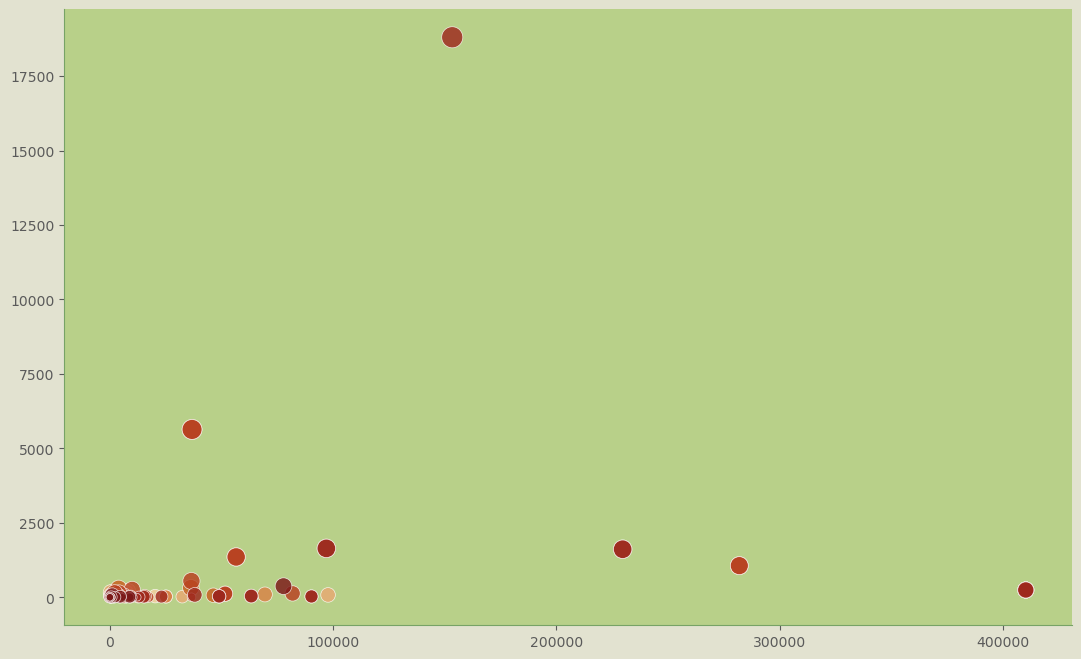

In [20]:
# SCATTER PLOT

fig3, ax3 = plt.subplots(figsize=(13, 8))
fig3.patch.set_facecolor(BG)
ax3.set_facecolor(PANEL)

year_vals = df_scatter['ArchiveYear'].values
year_norm = (year_vals - year_vals.min()) / (year_vals.max() - year_vals.min())
dot_sizes = np.log1p(df_scatter['StructuresDestroyed']) * 22 + 14

sc = ax3.scatter(
    df_scatter['AcresBurned'],
    df_scatter['StructuresDestroyed'],
    c=year_norm, cmap=fire_cmap,
    s=dot_sizes, alpha=0.82,
    edgecolors='white', linewidths=0.5, zorder=3)

In [21]:
# Colorbar
cbar = fig3.colorbar(sc, ax=ax3, pad=0.012, shrink=0.62, aspect=20)
cbar.set_label('Year', color=C_TEXT, fontsize=10.5, labelpad=8)
tl = np.linspace(0, 1, 7)
cbar.set_ticks(tl)
cbar.set_ticklabels([str(int(2013 + t*6)) for t in tl])
plt.setp(cbar.ax.yaxis.get_ticklabels(), color=C_TEXT, fontsize=9)
cbar.outline.set_edgecolor(BORDER)

ax3.set_xscale('log')
ymax = df_scatter['StructuresDestroyed'].max() * 1.13

In [22]:
# Danger zone
ax3.axhspan(5000, ymax, alpha=0.07, color=C_RED, zorder=0)
ax3.text(0.982, 0.965,
         '⚠  Catastrophic zone  (> 5,000 structures)',
         transform=ax3.transAxes, fontsize=9.5,
         color=C_RED, ha='right', va='top', style='italic',
         bbox=dict(boxstyle='round,pad=0.4', facecolor=C_DNGR,
                   edgecolor=C_RED, linewidth=0.9))

Text(0.982, 0.965, '⚠  Catastrophic zone  (> 5,000 structures)')

In [23]:
# 10K acre threshold
ax3.axvline(10000, color=C_SUB, linestyle=':', linewidth=1.3, alpha=0.65)
ax3.text(10500, 220, '10K acre threshold',
         fontsize=8.5, color=C_SUB, style='italic')

Text(10500, 220, '10K acre threshold')

In [24]:
# Annotate top fires
top4 = df_scatter.nlargest(4, 'StructuresDestroyed')
annot_cfg = [
    dict(xytext=(30000, 11000), label='Camp Fire\n(2018)'),
    dict(xytext=(8000,  4200),  label='Tubbs Fire\n(2017)'),
    dict(xytext=(55000, 2100),  label='Woolsey Fire\n(2018)'),
    dict(xytext=(12000, 1500),  label='Thomas Fire\n(2017)'),
]
for (_, row), cfg in zip(top4.iterrows(), annot_cfg):
    ax3.annotate(
        cfg['label'],
        xy=(row['AcresBurned'], row['StructuresDestroyed']),
        xytext=cfg['xytext'],
        fontsize=9, color=C_TEXT, fontweight='bold',
        arrowprops=dict(arrowstyle='->', color=C_AMBER,
                        lw=1.4, connectionstyle='arc3,rad=-0.2'),
        bbox=dict(boxstyle='round,pad=0.38', facecolor=C_CALL,
                  edgecolor=C_AMBER, linewidth=0.9))

In [25]:
# Insight callout
ax3.text(0.01, 0.975,
         '💡 Key Insight: Most fires destroy very few structures\n'
         '    even at large scale. Proximity to populated areas —\n'
         '    not fire size alone — drives catastrophic loss.',
         transform=ax3.transAxes, fontsize=9.5, color=C_TEXT, va='top',
         bbox=dict(boxstyle='round,pad=0.55', facecolor=C_CALL,
                   edgecolor=C_AMBER, linewidth=1.1))

Text(0.01, 0.975, '💡 Key Insight: Most fires destroy very few structures\n    even at large scale. Proximity to populated areas —\n    not fire size alone — drives catastrophic loss.')

In [26]:
# Dot-size legend
for sv, lbl in [(30,'30'), (300,'300'), (2000,'2,000')]:
    ax3.scatter([], [], s=np.log1p(sv)*22+14,
                color='#AAAAAA', edgecolors='white',
                linewidths=0.4, label=f'{lbl} structures', alpha=0.85)
ax3.legend(title='Dot = Structures Destroyed', title_fontsize=8.5,
           fontsize=8.5, loc='lower right',
           facecolor=PANEL, edgecolor=BORDER,
           labelcolor=C_TEXT, framealpha=0.95)

ax3.set_ylim(bottom=-200, top=ymax)
ax3.set_xlabel('Acres Burned  (log scale)', fontsize=11.5,
               labelpad=10, color=C_TEXT)
ax3.set_ylabel('Structures Destroyed', fontsize=11.5,
               labelpad=10, color=C_TEXT)
ax3.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))
ax3.tick_params(axis='both', colors=C_SUB, labelsize=9)
ax3.grid(alpha=0.35, which='both', zorder=0)
ax3.spines['bottom'].set_color(BORDER)
ax3.spines['left'].set_color(BORDER)


In [27]:
# Titles
fig3.text(0.07, 0.97,
          'DOES BIGGER ALWAYS MEAN MORE DESTRUCTIVE?',
          fontsize=18, fontweight='bold', color=C_RED,
          transform=fig3.transFigure, va='top')
fig3.text(0.07, 0.93,
          'Individual Fire: Acres Burned vs. Structures Destroyed  |  Dot size ∝ damage scale  |  Color = year',
          fontsize=11, color=C_SUB,
          transform=fig3.transFigure, va='top')

plt.subplots_adjust(top=0.89, bottom=0.09, left=0.09, right=0.90)
plt.savefig('plot3_scatter_firesize.png', dpi=180,
            bbox_inches='tight', facecolor=BG)
plt.close()
print(" Chart 3 saved → plot3_scatter_firesize.png")

 Chart 3 saved → plot3_scatter_firesize.png


In [28]:
# ── SUMMARY TABLE ────────────────────────────────────────────
print("\n[5/5] Summary Table:")
print("=" * 68)
print(f"{'Year':<6} {'Incidents':>10} {'Acres Burned':>14} {'Structures':>12} {'Deaths':>8}")
print("-" * 68)
for _, r in yearly.iterrows():
    print(f"{int(r['ArchiveYear']):<6} {int(r['Incidents']):>10,} "
          f"{int(r['TotalAcres']):>14,} {int(r['TotalStructures']):>12,} "
          f"{int(r['TotalFatalities']):>8,}")
print("=" * 68)
total = int(yearly['TotalAcres'].sum())

print(f"\n  Total acres burned   : {total:,}")
print(f"  Structures destroyed : {int(yearly['TotalStructures'].sum()):,}")
print(f"  Total fatalities     : {int(yearly['TotalFatalities'].sum()):,}")
print(f"  2018 share of acres  : {yearly[yearly['ArchiveYear']==2018]['TotalAcres'].values[0]/total*100:.1f}%")
print("\n" + "=" * 62)
print("  ALL DONE!")

print("    plot1_bar_counties.png")
print("    plot2_line_yearly.png")
print("    plot3_scatter_firesize.png")
print("=" * 62)


[5/5] Summary Table:
Year    Incidents   Acres Burned   Structures   Deaths
--------------------------------------------------------------------
2013          160        527,745          428        0
2014          116        448,715          634        0
2015          150        574,503          381        1
2016          179        505,927          774        0
2017          425      1,793,915       17,961       75
2018          312      3,358,049       26,855      102
2019          263        285,708          530        3

  Total acres burned   : 7,494,562
  Structures destroyed : 47,563
  Total fatalities     : 181
  2018 share of acres  : 44.8%

  ALL DONE!
    plot1_bar_counties.png
    plot2_line_yearly.png
    plot3_scatter_firesize.png
